C:\Users\carine\AppData\Local\Temp\ipykernel_12740\1225927292.py:7: DtypeWarning: Columns (0: code_commune) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DATASET_PRET_POUR_MACHINE_LEARNING.csv')


--- Structure du Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 4640555 entries, 0 to 4640554
Data columns (total 30 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   surface_reelle_bati        float64
 1   nombre_pieces_principales  int64  
 2   surface_terrain            float64
 3   valeur_fonciere            float64
 4   annee                      int64  
 5   mois                       int64  
 6   code_departement           int64  
 7   longitude                  float64
 8   latitude                   float64
 9   is_maison                  int64  
 10  is_neuf                    int64  
 11  anciennete_mois            int64  
 12  commune_prix_m2            float64
 13  commune_volume             int64  
 14  dist_primaire              float64
 15  dist_college               float64
 16  dist_lycee                 float64
 17  dist_superieur             float64
 18  dist_prive                 float64
 19  marche_primaire         

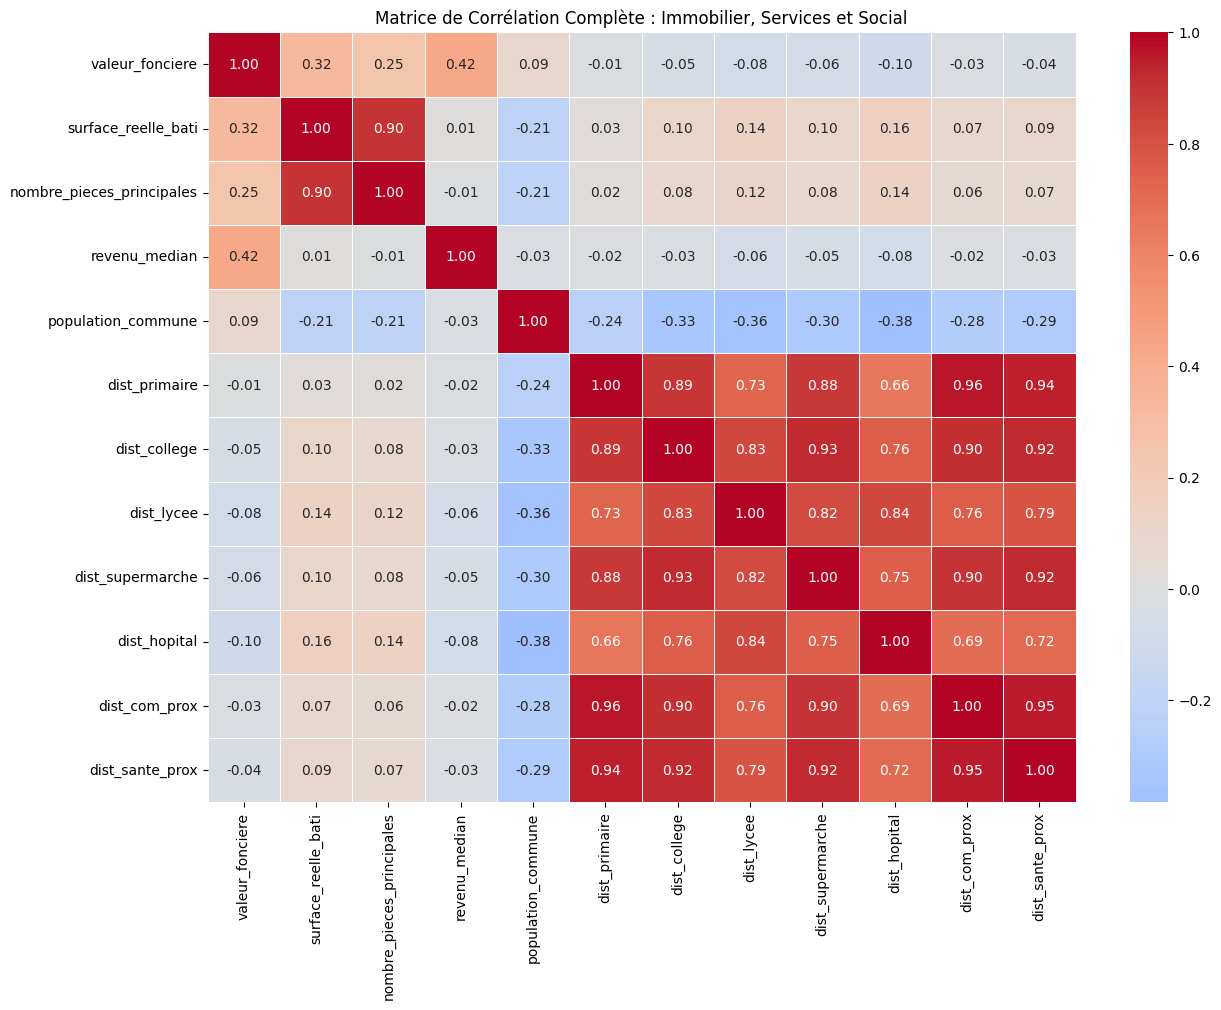


--- Influence directe sur la Valeur Foncière (triée) ---
valeur_fonciere              1.000000
revenu_median                0.422759
surface_reelle_bati          0.319822
nombre_pieces_principales    0.245563
population_commune           0.086970
dist_primaire               -0.010270
dist_com_prox               -0.031382
dist_sante_prox             -0.039789
dist_college                -0.050005
dist_supermarche            -0.061414
dist_lycee                  -0.081968
dist_hopital                -0.100282
Name: valeur_fonciere, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Rechargement du dataset final
df = pd.read_csv('DATASET_PRET_POUR_MACHINE_LEARNING.csv')

# 2. Visualisation des colonnes et types
print("--- Structure du Dataset ---")
print(df.info())

# 3. Préparation de la Heatmap
# On ne garde que les colonnes numériques pour la corrélation
# On exclut les codes postaux ou ID qui n'ont pas de sens mathématique
# Sélection avec tes noms de colonnes exacts
# Sélection élargie pour une vision complète
cols_pour_correlation = [
    'valeur_fonciere', 
    'surface_reelle_bati', 
    'nombre_pieces_principales',
    'revenu_median', 
    'population_commune',
    'dist_primaire', 
    'dist_college', 
    'dist_lycee', 
    'dist_supermarche', 
    'dist_hopital',
    'dist_com_prox', 
    'dist_sante_prox'
]

# Filtrage de sécurité (au cas où)
cols_existantes = [c for c in cols_pour_correlation if c in df.columns]

# Calcul de la matrice
corr_matrix = df[cols_existantes].corr()

# Affichage de la Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation Complète : Immobilier, Services et Social")
plt.show()

# Petit bonus : affichage des corrélations uniquement avec le prix, triées
print("\n--- Influence directe sur la Valeur Foncière (triée) ---")
print(corr_matrix['valeur_fonciere'].sort_values(ascending=False))

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Sélection des colonnes (on garde les mêmes)
features = [
    'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain',
    'latitude', 'longitude', 'is_maison', 'is_neuf', 'revenu_median',
    'population_commune', 'dist_primaire', 'dist_college', 'dist_lycee',
    'dist_supermarche', 'dist_hopital', 'dist_com_prox', 'dist_sante_prox'
]

X = df[features]
y = df['valeur_fonciere']

# --- PETITE SÉCURITÉ ---
# On s'assure qu'il n'y a plus de NaN (XGBoost n'aime pas les surprises)
X = X.fillna(0) 
y = y.fillna(y.median())

# 2. Split Train/Test (CORRIGÉ : test_size au lieu de test_test_split)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Création du modèle XGBoost
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist', # Très important pour tes 4,6 millions de lignes
    device="cpu"
)

print("🚀 Lancement de l'entraînement sur 4,6 millions de lignes...")
model_xgb.fit(X_train, y_train)
print("✅ Modèle entraîné avec succès !")

🚀 Lancement de l'entraînement sur 4,6 millions de lignes...
✅ Modèle entraîné avec succès !


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# On demande au modèle de prédire les prix sur les données de test (qu'il n'a jamais vues)
y_pred = model_xgb.predict(X_test)

# Calcul des métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"--- Résultats du Modèle ---")
print(f"Score R² : {r2:.4f} (Proche de 1 = Excellent)")
print(f"Erreur Moyenne (MAE) : {mae:.2f} €")
print(f"Erreur en % (MAPE) : {mape*100:.2f} %")

--- Résultats du Modèle ---
Score R² : 0.6827 (Proche de 1 = Excellent)
Erreur Moyenne (MAE) : 69889.81 €
Erreur en % (MAPE) : 40.08 %


<Figure size 1000x800 with 0 Axes>

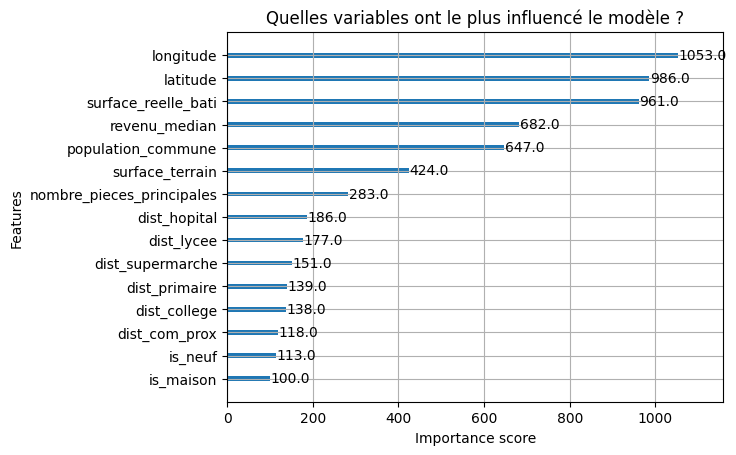

In [8]:
# Affichage de l'importance des variables
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, importance_type='weight', max_num_features=15)
plt.title("Quelles variables ont le plus influencé le modèle ?")
plt.show()

In [9]:
## Filtrage valeurs aberrantes
# Exemple : On ne garde que les biens entre 50 000€ et 1 500 000€
df_filtered = df[(df['valeur_fonciere'] > 50000) & (df['valeur_fonciere'] < 1500000)]

In [10]:
## Gridsearch
from sklearn.model_selection import GridSearchCV

# 1. On prend un échantillon pour que ça ne dure pas 3 jours
df_sample = df_filtered.sample(n=100000, random_state=42)
X_sample = df_sample[features]
y_sample = df_sample['valeur_fonciere']

# 2. On définit les paramètres à tester
param_grid = {
    'max_depth': [6, 8, 10],           # Profondeur des arbres
    'learning_rate': [0.05, 0.1],       # Vitesse d'apprentissage
    'n_estimators': [100, 200],         # Nombre d'arbres
    'colsample_bytree': [0.8, 1.0]      # % de colonnes utilisées par arbre
}

# 3. On lance la recherche
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(tree_method='hist', device="cpu"),
    param_grid=param_grid,
    cv=3,              # Découpe en 3 pour valider
    scoring='r2',
    verbose=2
)

grid_search.fit(X_sample, y_sample)

print("--- Meilleurs paramètres trouvés ---")
print(grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, n_estimators=100; total time=   1.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, n_estimators=100; total time=   1.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, n_estimators=100; total time=   2.1s
[CV] END colsample_bytree=0.8,

In [11]:
# 1. On utilise les paramètres trouvés par le GridSearch
model_final = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    colsample_bytree=0.8,
    tree_method='hist',
    device="cpu", # Passe à "cuda" si tu as un GPU
    random_state=42
)

# 2. Entraînement sur tout le dataset filtré
print("🏗️ Entraînement du modèle final en cours (cela va prendre un peu plus de temps)...")
model_final.fit(X_train, y_train)

# 3. Nouvelles prédictions
y_pred_final = model_final.predict(X_test)

# 4. Calcul des performances
from sklearn.metrics import r2_score, mean_absolute_percentage_error
new_r2 = r2_score(y_test, y_pred_final)
new_mape = mean_absolute_percentage_error(y_test, y_pred_final)

print(f"--- 🏆 Performances du Modèle Champion ---")
print(f"Nouveau Score R² : {new_r2:.4f}")
print(f"Nouveau MAPE : {new_mape*100:.2f} %")

🏗️ Entraînement du modèle final en cours (cela va prendre un peu plus de temps)...
--- 🏆 Performances du Modèle Champion ---
Nouveau Score R² : 0.7414
Nouveau MAPE : 35.46 %


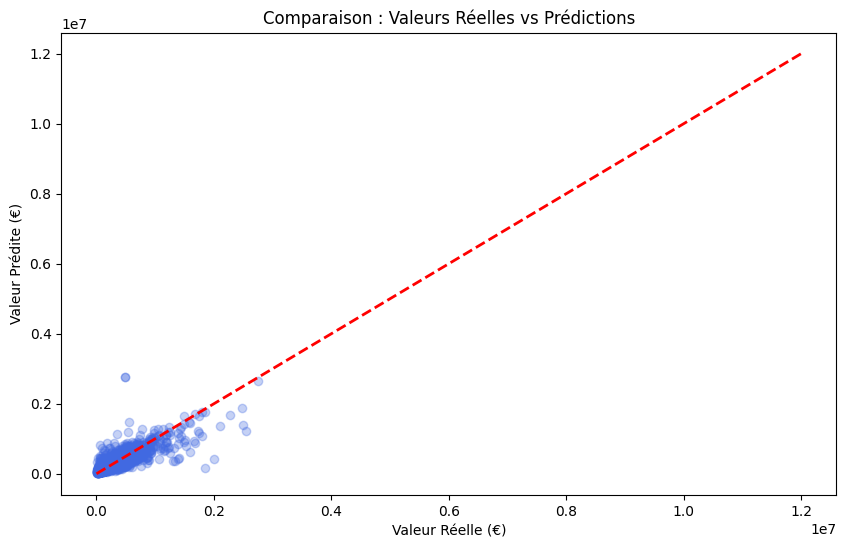

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# On prend un échantillon pour la lisibilité du graphique
sample_idx = np.random.choice(len(y_test), 5000)
plt.scatter(y_test.iloc[sample_idx], y_pred_final[sample_idx], alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeur Réelle (€)')
plt.ylabel('Valeur Prédite (€)')
plt.title('Comparaison : Valeurs Réelles vs Prédictions')
plt.show()

In [13]:
# On regarde l'erreur par tranche de prix
df_test_res = pd.DataFrame({'Reel': y_test, 'Pred': y_pred_final})
df_test_res['Erreur_Abs_Pct'] = np.abs((df_test_res['Reel'] - df_test_res['Pred']) / df_test_res['Reel']) * 100

print("--- Erreur moyenne par tranche de prix ---")
bins = [0, 150000, 300000, 600000, 1500000]
labels = ['<150k€', '150k-300k€', '300k-600k€', '>600k€']
df_test_res['Tranche'] = pd.cut(df_test_res['Reel'], bins=bins, labels=labels)
print(df_test_res.groupby('Tranche')['Erreur_Abs_Pct'].mean())

--- Erreur moyenne par tranche de prix ---
Tranche
<150k€        58.800744
150k-300k€    21.000015
300k-600k€    20.210631
>600k€        23.849679
Name: Erreur_Abs_Pct, dtype: float64


## LightGBM,

In [15]:
import lightgbm as lgb
from sklearn.linear_model import LinearRegression

# 1. On définit le modèle LightGBM avec des paramètres solides
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=10,
    device="cpu",
    random_state=42
)

print("🌿 Entraînement de LightGBM...")
model_lgb.fit(X_train, y_train)

# 2. On récupère les prédictions des deux modèles sur le set de test
pred_xgb = model_xgb.predict(X_test) # Ton modèle champion précédent
pred_lgb = model_lgb.predict(X_test)

🌿 Entraînement de LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.323520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3345
[LightGBM] [Info] Number of data points in the train set: 3712444, number of used features: 16
[LightGBM] [Info] Start training from score 244794.359857


--- 🌿 Score LightGBM seul ---
R² : 0.7302
MAPE : 37.14 %


C:\Users\carine\AppData\Local\Temp\ipykernel_12740\3626121351.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=lgb_importance, palette='viridis')


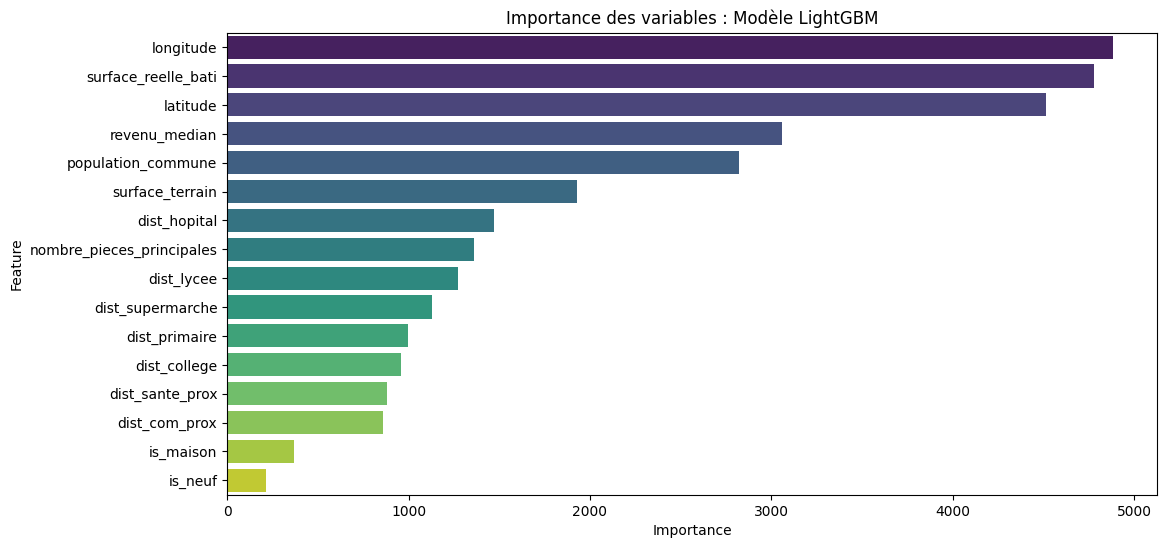

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul des métriques pour LightGBM
pred_lgb = model_lgb.predict(X_test)
lgb_r2 = r2_score(y_test, pred_lgb)
lgb_mape = mean_absolute_percentage_error(y_test, pred_lgb)

print(f"--- 🌿 Score LightGBM seul ---")
print(f"R² : {lgb_r2:.4f}")
print(f"MAPE : {lgb_mape*100:.2f} %")

# 2. Comparaison visuelle des Feature Importances
lgb_importance = pd.DataFrame({'Feature': features, 'Importance': model_lgb.feature_importances_})
lgb_importance = lgb_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=lgb_importance, palette='viridis')
plt.title('Importance des variables : Modèle LightGBM')
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.358750 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3345
[LightGBM] [Info] Number of data points in the train set: 3712444, number of used features: 16
[LightGBM] [Info] Start training from score 244794.359857
[50]	valid_0's rmse: 151754	valid_0's l2: 2.30293e+10
[100]	valid_0's rmse: 140963	valid_0's l2: 1.98705e+10
[150]	valid_0's rmse: 136635	valid_0's l2: 1.86691e+10
[200]	valid_0's rmse: 134390	valid_0's l2: 1.80607e+10
[250]	valid_0's rmse: 132969	valid_0's l2: 1.76809e+10
[300]	valid_0's rmse: 131836	valid_0's l2: 1.73809e+10
[350]	valid_0's rmse: 131008	valid_0's l2: 1.71632e+10
[400]	valid_0's rmse: 130365	valid_0's l2: 1.69951e+10
[450]	valid_0's rmse: 129822	valid_0's l2: 1.68538e+10
[500]	valid_0's rmse: 129289	valid_0's l2: 1.67157e+10


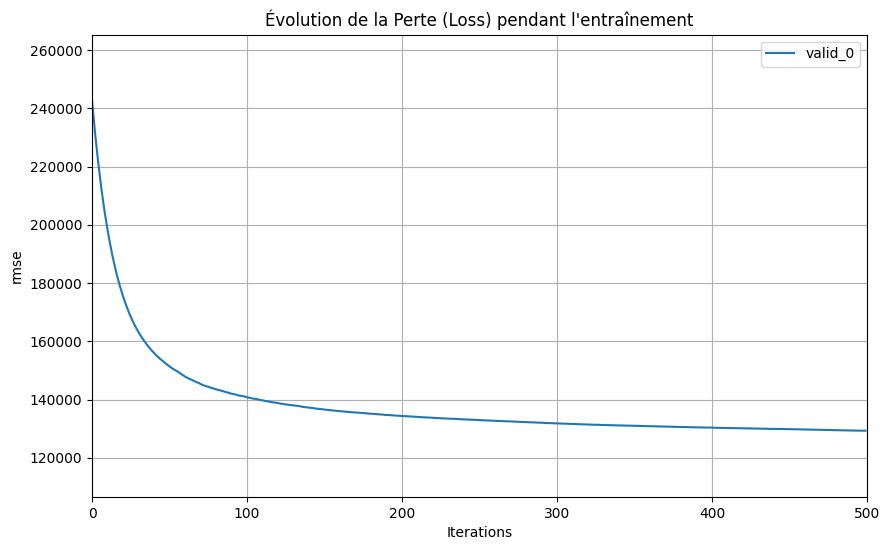

In [17]:
# Note : Pour afficher la loss, il faut avoir passé un eval_set lors du .fit()
# Si tu ne l'as pas fait, voici comment relancer rapidement la fin de l'entraînement avec historique
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.log_evaluation(period=50)]
)

# Visualisation de la Loss
lgb.plot_metric(model_lgb, metric='rmse', figsize=(10, 6))
plt.title("Évolution de la Perte (Loss) pendant l'entraînement")
plt.show()

## Stacking

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 1. On récupère les prédictions des deux modèles sur le même set de test
pred_xgb = model_xgb.predict(X_test)
pred_lgb = model_lgb.predict(X_test)

# 2. On empile les prédictions pour créer une nouvelle matrice de données
# Chaque ligne aura deux colonnes : [Prix_prédit_XGB , Prix_prédit_LGB]
X_stacked = np.column_stack((pred_xgb, pred_lgb))

# 3. On entraîne le "Méta-Modèle"
meta_model = LinearRegression()
meta_model.fit(X_stacked, y_test)

# 4. On génère la prédiction finale combinée
final_predictions = meta_model.predict(X_stacked)

# --- RÉSULTATS ---
print(f"--- ⚖️ Poids attribués par le Méta-Modèle ---")
print(f"Coefficient XGBoost : {meta_model.coef_[0]:.4f}")
print(f"Coefficient LightGBM : {meta_model.coef_[1]:.4f}")
print(f"Constante (Biais) : {meta_model.intercept_:.2f} €")

print(f"\n--- 🚀 Performances Finales du STACKING ---")
print(f"Score R² Global : {r2_score(y_test, final_predictions):.4f}")
print(f"Nouveau MAPE : {mean_absolute_percentage_error(y_test, final_predictions)*100:.2f} %")

--- ⚖️ Poids attribués par le Méta-Modèle ---
Coefficient XGBoost : -0.4064
Coefficient LightGBM : 1.4014
Constante (Biais) : 1359.68 €

--- 🚀 Performances Finales du STACKING ---
Score R² Global : 0.7344
Nouveau MAPE : 36.97 %


In [19]:
# Moyenne simple 50/50
pred_moyenne = (pred_xgb + pred_lgb) / 2

print(f"--- 📊 Score Moyenne Simple (50/50) ---")
print(f"R² : {r2_score(y_test, pred_moyenne):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, pred_moyenne)*100:.2f} %")

--- 📊 Score Moyenne Simple (50/50) ---
R² : 0.7131
MAPE : 38.26 %


## TEST DU MODELE AVEC ESSAI PREDICTION

In [20]:
import pandas as pd

# On crée le dictionnaire avec les caractéristiques de ta maison
maison_quinssaines = pd.DataFrame([{
    'surface_reelle_bati': 130,
    'nombre_pieces_principales': 5, # Estimé pour 130m2
    'surface_terrain': 4500,        # Tes 45 ares
    'latitude': 46.327,
    'longitude': 2.511,
    'is_maison': 1,
    'is_neuf': 0,
    'revenu_median': 22500,
    'population_commune': 1500,
    'dist_hopital': 8.5,
    'dist_lycee': 7.0,
    'dist_supermarche': 4.0,
    'dist_primaire': 1.0,
    'dist_college': 7.0,
    'dist_com_prox': 1.5,
    'dist_sante_prox': 2.0
}])

# Prédiction avec ton XGBoost Champion
prix_estime = model_xgb.predict(maison_quinssaines[features])[0]

print(f"--- 🏠 Estimation Immobilière (Quinssaines) ---")
print(f"Caractéristiques : 130m², 4500m² de terrain")
print(f"Prix estimé par l'IA : {prix_estime:,.2f} €")

--- 🏠 Estimation Immobilière (Quinssaines) ---
Caractéristiques : 130m², 4500m² de terrain
Prix estimé par l'IA : 174,010.72 €


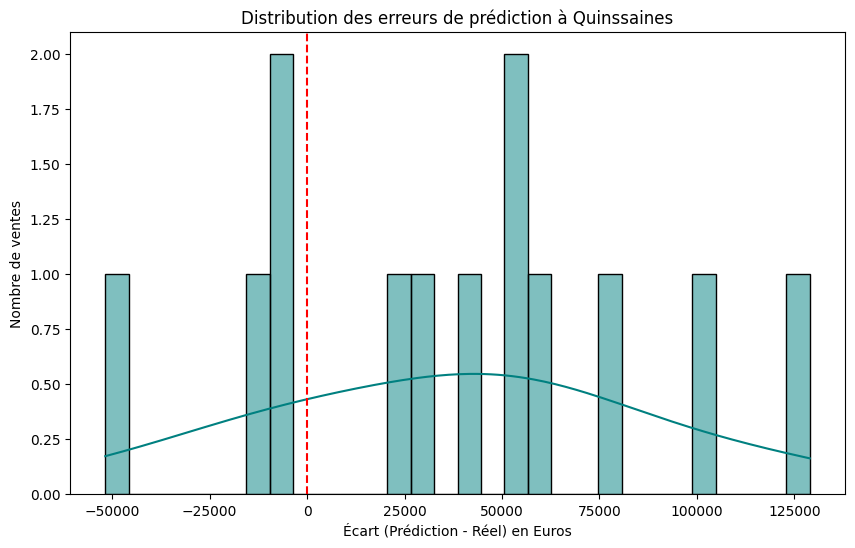

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On crée un DataFrame de test avec les prédictions et les infos de localisation
df_analyse = X_test.copy()
df_analyse['Prix_Reel'] = y_test
df_analyse['Prix_Predit'] = model_xgb.predict(X_test)
df_analyse['Erreur'] = df_analyse['Prix_Predit'] - df_analyse['Prix_Reel']

# 2. On filtre sur les coordonnées approximatives de Quinssaines
# (On utilise une petite marge car les points GPS varient légèrement)
quinssaines_mask = (df_analyse['latitude'].between(46.31, 46.34)) & \
                   (df_analyse['longitude'].between(2.49, 2.53))

df_quin = df_analyse[quinssaines_mask]

# 3. Affichage de la distribution des erreurs
plt.figure(figsize=(10, 6))
sns.histplot(df_quin['Erreur'], kde=True, color='teal', bins=30)
plt.axvline(0, color='red', linestyle='--') # La ligne du "zéro erreur"
plt.title('Distribution des erreurs de prédiction à Quinssaines')
plt.xlabel('Écart (Prédiction - Réel) en Euros')
plt.ylabel('Nombre de ventes')
plt.show()

## SAUVERGARDE DU MODELE

In [21]:
# Sauvegarde au format JSON (lisible et universel)
model_xgb.save_model('modele_immobilier_final.json')

# Pour le charger :
# import xgboost as xgb
# model_charge = xgb.XGBRegressor()
# model_charge.load_model('modele_immobilier_final.json')

In [22]:
import json
from datetime import datetime

# Création du dictionnaire de configuration
model_config = {
    "model_name": "Estimateur Immobilier France",
    "version": "1.0",
    "date_entrainement": datetime.now().strftime("%d/%m/%Y %H:%M"),
    "features_order": list(X_train.columns), # L'ordre CRITIQUE des colonnes
    "target": "valeur_fonciere",
    "filtre_prix_min": 50000,
    "filtre_prix_max": 1500000,
    "r2_score": 0.7414,
    "mape_score": 35.46
}

# Sauvegarde dans un fichier JSON
with open('config_modele.json', 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=4, ensure_ascii=False)

print("✅ Fichier 'config_modele.json' créé avec succès !")

✅ Fichier 'config_modele.json' créé avec succès !
